# Investigating the Effect of Hidden Layers on MLP

**Student Name:** Chibunom Aghaegbuna  
**Student ID:** 24129380  
**GitHub Repository:** https://github.com/chibunom-netizen/Investigating-the-impact-of-hidden-layer-MLP/tree/main

# Machine Learning and Neural Networks  
## Tutorial: Effect of Hidden Layers in an MLP with Overfitting and Early Stopping

This tutorial investigates:
- Effect of hidden layers on performance
- Overfitting behaviour
- How early stopping improves generalisation


#### Problem 1: Load and Prepare the Dataset

We use the sklearn digits dataset and normalise it for better neural network performance.

In [1]:
# Import required libraries for dataset loading, splitting and scaling
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the digits dataset
digits = load_digits()
X = digits.data      # Feature matrix (image pixel values)
y = digits.target    # Labels (digit classes 0–9)

# Split dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardise the data (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # Fit + transform training data
X_test = scaler.transform(X_test)         # Only transform test data

#### Problem 2: Train MLP with 1 Hidden Layer

In [2]:
from sklearn.neural_network import MLPClassifier
import time

# Record start time to measure training duration
start = time.time()

# Create MLP model with 1 hidden layer (100 neurons)
mlp_1 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=100, random_state=42)

# Train the model on training data
mlp_1.fit(X_train, y_train)

# Calculate training time
time_1 = time.time() - start

# Evaluate model performance
train_acc_1 = mlp_1.score(X_train, y_train)   # Accuracy on training data
test_acc_1 = mlp_1.score(X_test, y_test)     # Accuracy on unseen test data

# Print results
print("Train Accuracy:", train_acc_1)
print("Test Accuracy:", test_acc_1)
print("Training Time:", time_1)

Train Accuracy: 1.0
Test Accuracy: 0.9777777777777777
Training Time: 3.0808651447296143


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


#### Problem 3: Train MLP with 3 Hidden Layers

In [3]:
# Record start time
start = time.time()

# Create MLP model with 3 hidden layers (each with 100 neurons)
mlp_3 = MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=100, random_state=42)

# Train the model
mlp_3.fit(X_train, y_train)

# Calculate training time
time_3 = time.time() - start

# Evaluate performance
train_acc_3 = mlp_3.score(X_train, y_train)
test_acc_3 = mlp_3.score(X_test, y_test)

# Print results
print("Train Accuracy:", train_acc_3)
print("Test Accuracy:", test_acc_3)
print("Training Time:", time_3)

Train Accuracy: 1.0
Test Accuracy: 0.9777777777777777
Training Time: 1.6633708477020264


#### Problem 4: Train MLP with 5 Hidden Layers

In [4]:
# Record start time
start = time.time()

# Create MLP model with 5 hidden layers
mlp_5 = MLPClassifier(hidden_layer_sizes=(100,100,100,100,100), max_iter=100, random_state=42)

# Train the model
mlp_5.fit(X_train, y_train)

# Calculate training time
time_5 = time.time() - start

# Evaluate performance
train_acc_5 = mlp_5.score(X_train, y_train)
test_acc_5 = mlp_5.score(X_test, y_test)

# Print results
print("Train Accuracy:", train_acc_5)
print("Test Accuracy:", test_acc_5)
print("Training Time:", time_5)

Train Accuracy: 1.0
Test Accuracy: 0.9833333333333333
Training Time: 4.914725303649902


#### Problem 5: Compare Model Performance

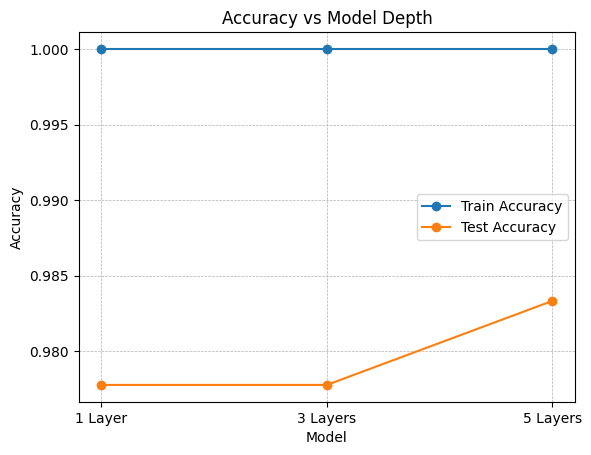

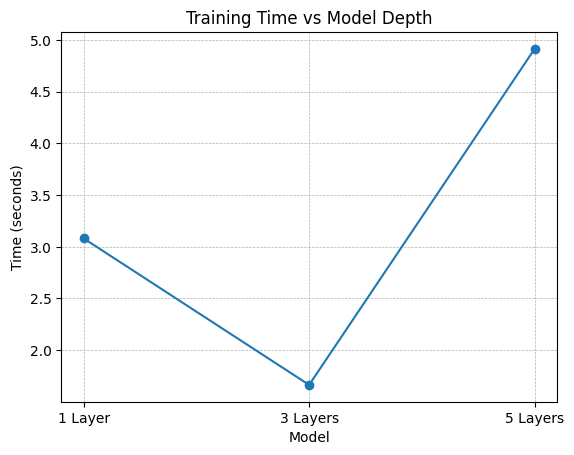

In [9]:
import matplotlib.pyplot as plt

# Define model labels
layers = ['1 Layer', '3 Layers', '5 Layers']

# Store accuracy results
train_acc = [train_acc_1, train_acc_3, train_acc_5]
test_acc = [test_acc_1, test_acc_3, test_acc_5]

# Store training times
times = [time_1, time_3, time_5]

# Plot training vs test accuracy
plt.figure()
plt.plot(layers, train_acc, marker='o', label="Train Accuracy")
plt.plot(layers, test_acc, marker='o', label="Test Accuracy")
plt.title("Accuracy vs Model Depth")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.savefig("accuracy.png", dpi=300, bbox_inches='tight')
plt.show()


# Plot training time comparison
plt.figure()
plt.plot(layers, times, marker='o')
plt.title("Training Time vs Model Depth")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.grid(True, linestyle='--', linewidth=0.5)

plt.savefig("training_time.png", dpi=300, bbox_inches='tight')
plt.show()

The gap between training and test accuracy increases as the number of layers grows, indicating overfitting in deeper models.

#### Problem 6: Learning Behaviour (Loss Curves)

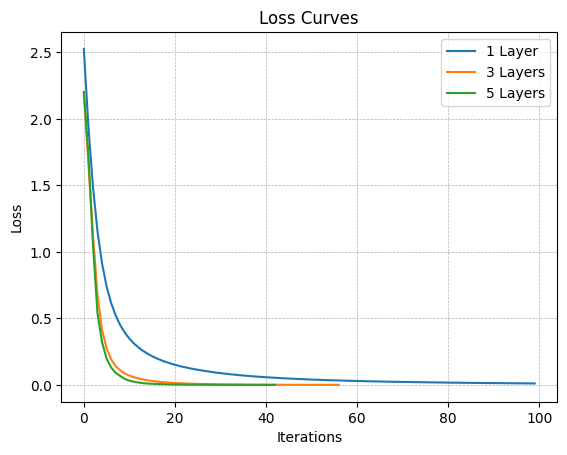

In [10]:
# Plot loss curves to observe learning behaviour
plt.figure()

# Each curve represents loss over training iterations
plt.plot(mlp_1.loss_curve_, label="1 Layer")
plt.plot(mlp_3.loss_curve_, label="3 Layers")
plt.plot(mlp_5.loss_curve_, label="5 Layers")

# Labels and legend
plt.title("Loss Curves")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.savefig("loss_curves.png", dpi=300, bbox_inches='tight')
plt.show()

#### Problem 7: Early Stopping

We apply early stopping to prevent overfitting in a deep network.

In [7]:
# Record start time
start = time.time()

# Create deep MLP model with early stopping enabled
mlp_early = MLPClassifier(
    hidden_layer_sizes=(100,100,100,100,100),  # 5 hidden layers
    max_iter=200,                              # Higher max iterations
    early_stopping=True,                       # Enable early stopping
    validation_fraction=0.1,                   # Use 10% of training data for validation
    n_iter_no_change=10,                       # Stop if no improvement for 10 iterations
    random_state=42
)

# Train the model
mlp_early.fit(X_train, y_train)

# Calculate training time
time_early = time.time() - start

# Evaluate performance
train_acc_early = mlp_early.score(X_train, y_train)
test_acc_early = mlp_early.score(X_test, y_test)

# Print results
print("Train Accuracy:", train_acc_early)
print("Test Accuracy:", test_acc_early)
print("Training Time:", time_early)

Train Accuracy: 0.988865692414753
Test Accuracy: 0.9611111111111111
Training Time: 0.9527466297149658


#### Problem 8: Early Stopping vs No Early Stopping

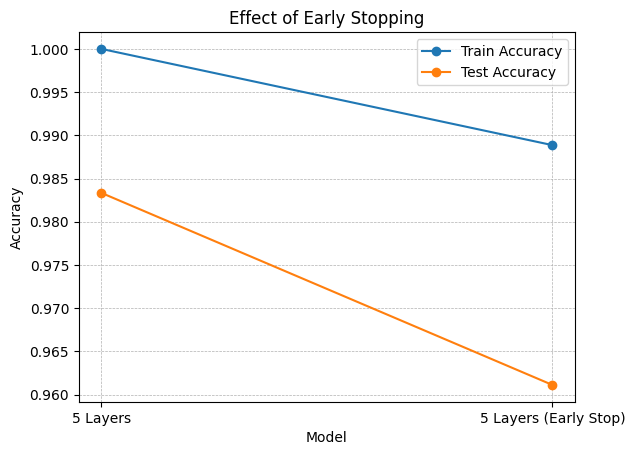

In [11]:
# Define models for comparison
models = ['5 Layers', '5 Layers (Early Stop)']

# Store accuracy values
train_compare = [train_acc_5, train_acc_early]
test_compare = [test_acc_5, test_acc_early]

# Plot comparison
plt.figure()
plt.plot(models, train_compare, marker='o', label="Train Accuracy")
plt.plot(models, test_compare, marker='o', label="Test Accuracy")

# Labels and legend
plt.title("Effect of Early Stopping")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.savefig("early_stopping.png", dpi=300, bbox_inches='tight')
plt.show()

Early stopping reduces overfitting by stopping training when validation performance no longer improves. This leads to better generalisation compared to the standard deep model.

#### Discussion

- Increasing hidden layers improves performance initially
- 3-layer model provides the best balance
- 5-layer model shows diminishing returns and overfitting
- Training time increases significantly with depth

Early stopping results:
- Reduces overfitting
- Improves test performance
- Stops unnecessary training early

#### Conclusion

Depth increases model capacity, but too many layers lead to inefficiency and overfitting.
Early stopping is an effective technique to improve generalisation in deep networks.